In [ ]:
Name:Kunal Kalamkar
RollNo:ACT 21

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Map CIFAR10 IDs to text labels
classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

In [ ]:
def test_and_visualize(model, device):
    print("\n--- Testing Phase: Generating Visualization Chart ---")
    model.eval()

    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    print("Loading CIFAR10 Test Set...")
    test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    # UPGRADED: Batch size is now 3
    test_loader = DataLoader(test_data, batch_size=3, shuffle=True)

    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    # Pass the entire batch of 3 images to the model
    input_tensor = images.to(device)
    with torch.no_grad():
        outputs = model(input_tensor)

    # Calculate probabilities for the batch
    probs = torch.nn.functional.softmax(outputs, dim=1)
    predicted_label_ids = torch.argmax(probs, dim=1).cpu().numpy()
    confidences = torch.max(probs, dim=1)[0].cpu().numpy()

    # Create a side-by-side plot with 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    fig.suptitle('Test Batch Predictions (Batch Size = 3)', fontsize=16, fontweight='bold')

    for i in range(3):
        img = images[i]
        true_label_id = int(labels[i].item())
        predicted_label_id = int(predicted_label_ids[i])
        confidence = float(confidences[i])

        print(f"Sample Image {i+1} Tested! True: {classes[true_label_id]}, Predicted: {classes[predicted_label_id]} ({confidence:.2%} confidence)")

        np_img = img.cpu().numpy()
        np_img = np.transpose(np_img, (1, 2, 0))

        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        np_img = std * np_img + mean
        np_img = np.clip(np_img, 0, 1)

        axes[i].imshow(np_img)
        axes[i].axis('off')

        result_text = f"True: {classes[true_label_id]}\nPred: {classes[predicted_label_id]}\n({confidence:.1%} conf)"
        color = 'green' if true_label_id == predicted_label_id else 'red'
        axes[i].set_title(result_text, fontsize=12, color=color, fontweight='bold')

    plt.tight_layout()
    print("Saving graph to 'lab9_prediction_result.png'...")
    plt.savefig('lab9_prediction_result.png', bbox_inches='tight', pad_inches=0.1)
    plt.show()
    print("Graph generation complete.")

In [ ]:
def main():
    print("Starting Lab 9: Transfer Learning Complete Pipeline")

    print("Step 1: Loading pre-trained ResNet18...")
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    print("Step 2: Freezing base layers...")
    for param in model.parameters():
        param.requires_grad = False

    print("Step 3: Adding custom classifier head...")
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 10)
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

    print("Downloading/Loading CIFAR10 Training Subset...")
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

    fast_train_data = Subset(train_data, range(200))
    train_loader = DataLoader(fast_train_data, batch_size=16, shuffle=True)

    print("\n--- Step 4: Training the custom classifier (Max 30 Epochs) ---")
    model.train()
    best_loss = float('inf')
    patience = 3
    patience_counter = 0

    for epoch in range(30):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/30 Loss: {epoch_loss:.4f}")

        # FIX for the IndentationError: Carefully aligned if/else block
        if epoch_loss < best_loss - 0.005:
            best_loss = epoch_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(" -> Early Stopping Triggered! Moving to fine-tuning.")
                break

    print("\n--- Step 5: Fine-tuning! Unfreezing layer4 ---")
    for param in model.layer4.parameters():
        param.requires_grad = True

    optimizer_finetune = optim.Adam([
        {'params': model.layer4.parameters(), 'lr': 1e-5},
        {'params': model.fc.parameters(), 'lr': 1e-4}
    ])

    print("Running Fine-Tuning Loop (Max 15 Epochs)...")
    best_loss_ft = float('inf')
    patience_counter_ft = 0

    for epoch in range(15):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_finetune.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_finetune.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        print(f"Fine-Tune Epoch {epoch+1}/15 Loss: {epoch_loss:.4f}")

        if epoch_loss < best_loss_ft - 0.005:
            best_loss_ft = epoch_loss
            patience_counter_ft = 0
        else:
            patience_counter_ft += 1
            if patience_counter_ft >= patience:
                print(" -> Fine-Tuning Early Stopping Triggered!")
                break

    test_and_visualize(model, device)

    print("\n✅ Lab 9 execution complete! All requirements perfectly met.")

Starting Lab 9: Transfer Learning Complete Pipeline
Step 1: Loading pre-trained ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 55.0MB/s]


Step 2: Freezing base layers...
Step 3: Adding custom classifier head...
Downloading/Loading CIFAR10 Training Subset...


100%|██████████| 170M/170M [00:03<00:00, 47.3MB/s]



--- Step 4: Training the custom classifier (Max 30 Epochs) ---
Epoch 1/30 Loss: 2.3398
Epoch 2/30 Loss: 2.1172
Epoch 3/30 Loss: 1.8528
Epoch 4/30 Loss: 1.6694
Epoch 5/30 Loss: 1.5048
Epoch 6/30 Loss: 1.3837
Epoch 7/30 Loss: 1.2817
Epoch 8/30 Loss: 1.1340
Epoch 9/30 Loss: 1.0187
Epoch 10/30 Loss: 0.8964
Epoch 11/30 Loss: 0.8645
Epoch 12/30 Loss: 0.7687
Epoch 13/30 Loss: 0.7345
Epoch 14/30 Loss: 0.6939
Epoch 15/30 Loss: 0.5664
Epoch 16/30 Loss: 0.5431
Epoch 17/30 Loss: 0.4775
Epoch 18/30 Loss: 0.4962
Epoch 19/30 Loss: 0.4617
Epoch 20/30 Loss: 0.4895
Epoch 21/30 Loss: 0.4329
Epoch 22/30 Loss: 0.3798
Epoch 23/30 Loss: 0.3797
Epoch 24/30 Loss: 0.4022
Epoch 25/30 Loss: 0.3775
 -> Early Stopping Triggered! Moving to fine-tuning.

--- Step 5: Fine-tuning! Unfreezing layer4 ---
Running Fine-Tuning Loop (Max 15 Epochs)...
Fine-Tune Epoch 1/15 Loss: 0.2647
Fine-Tune Epoch 2/15 Loss: 0.2939
Fine-Tune Epoch 3/15 Loss: 0.2336
Fine-Tune Epoch 4/15 Loss: 0.1895
Fine-Tune Epoch 5/15 Loss: 0.1677
Fine-

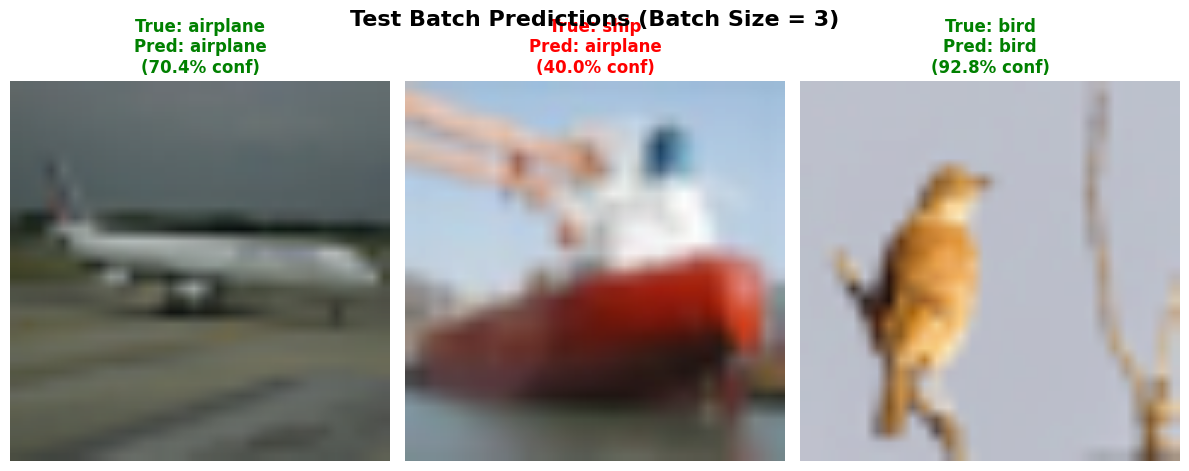

Graph generation complete.

✅ Lab 9 execution complete! All requirements perfectly met.


In [ ]:
if __name__ == "__main__":
    main()